In [1]:
## 0 === Standard Startup Template ===
import os, random
import numpy as np
import torch

# --- Project Path Setup ---
root        = r"C:\AI_research"
dataset_dir = os.path.join(root, "dataset", "train_colored")
output_dir  = os.path.join(root, "outputs", "blurred_test")
ckpt_dir    = os.path.join(root, "outputs", "checkpoints")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

#deterministic set up
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
print("CUBLAS_WORKSPACE_CONFIG =", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# --- Device Setup ---
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# --- Reproducibility Setup ---
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False

print(f"Reproducibility mode ON (seed = {seed})")

# --- Constants ---
img_size   = 256
batch_size = 4
fraunhofer = "triangle"  # None(gaussian) | "circle" | "triangle" | "diamond"

CUBLAS_WORKSPACE_CONFIG = :4096:8
PyTorch version: 2.7.1+cu118
Using device: cuda
CUDA device: NVIDIA GeForce RTX 4060 Ti
Reproducibility mode ON (seed = 42)


In [2]:
## 1.0 Dataset Class + Modular Blur Function 
import os
import cv2
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# === PyTorch Dataset Class === ##Pipeline critical
class SharpSignageDataset(Dataset):
    def __init__(self, img_dir, img_size=256):
        # Only need sharp image paths
        self.img_paths = [
            os.path.join(img_dir, f)
            for f in os.listdir(img_dir)
            if f.lower().endswith(".png")
        ]
        self.img_size = img_size
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Load and preprocess sharp image
        img = cv2.imread(self.img_paths[idx], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        sharp_tensor = self.to_tensor(img)
        return sharp_tensor

In [3]:
### 1.1 Set Blur Kernels + Create Dataset ##pipeline critical 

# Use a common sigma for all channels so all kernels have the same size
common_sigma = 1.0
blur_sigmas = {ch: common_sigma for ch in ['R','G','B']}

# === Load your dataset ===
img_dir = dataset_dir

# Note: SharpSignageDataset now only needs img_dir and img_size
dataset = SharpSignageDataset(img_dir, img_size=256)

In [4]:
### 1.2 Create DataLoader + Inspect ##pipeline critical
from torch.utils.data import DataLoader, random_split

# Assume `dataset` is your SharpSignageDataset that only returns sharp tensors
# 90/10 train–val split
train_size = int(0.9 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# Create loaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

# Quick sanity check: each batch is just the sharp input
for batch in train_loader:
    print("Batch shape (sharp):", batch.shape)  # should be (B, 3, 256, 256)
    break

Batch shape (sharp): torch.Size([4, 3, 256, 256])


In [5]:
### 1.3 Kernel Generator fot pythorch  ##gaussian training
import torch
import torch.nn.functional as F
import math

def create_gaussian_kernel(sigma, tol=1e-6):
    # 1) compute odd ksize ≃ ⌈8σ⌉
    k = math.ceil(8 * sigma)
    if k % 2 == 0:
        k += 1

    # 2) sample the 2D Gaussian
    ax = torch.arange(k, device=device) - k//2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    raw = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # 3) normalize and assert sum = 1
    kernel = raw / raw.sum()
    s = float(kernel.sum())
    assert abs(s - 1.0) < tol, f"Kernel sum {s:.6f} ≠ 1 (σ={sigma})"

    return k,  kernel

In [6]:
###Build Per-Channel Kernels for F.conv2d ###Pipeline critical
def build_blur_kernels(blur_sigmas):
    kernels = []
    
    # --- THE FIX IS HERE ---
    # Directly loop over the sigma values in the dictionary
    for sigma in blur_sigmas.values():
        
        # Unpack the tuple, assigning the size to '_' (to ignore it) 
        # and the tensor to 'k'.
        _, k = create_gaussian_kernel(sigma)
        
        k_tensor = k.unsqueeze(0).unsqueeze(0)     # [1,1,k,k]
        kernels.append(k_tensor)
        
    return torch.cat(kernels, dim=0)

In [7]:
###Differentiable Reblur Function  
import torch.nn.functional as F

def reblur_tensor(image_tensor, kernel_tensor):
    """
    image_tensor: [B, 3, H, W]
    kernel_tensor: [3, 1, k, k]
    """
    B, C, H, W = image_tensor.shape
    k = kernel_tensor.shape[-1]

    # Expand kernels for grouped convolution
    kernel = kernel_tensor.to(image_tensor.device)             # [3, 1, k, k]

    # Apply per-channel blur using groups=3
    return F.conv2d(image_tensor, kernel, padding=k//2, groups=3)
    
# Rebuild the differentiable kernel tensor
kernel_tensor = build_blur_kernels(blur_sigmas).to(device)

In [8]:
### Residual U-net ### ##Pipeline critical
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualUNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()

        # -------- encoder --------
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch,   base, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base,    base, 3, padding=1), nn.ReLU(inplace=True)
        )
        self.down1 = nn.MaxPool2d(2)                    # 1/2

        self.enc2 = nn.Sequential(
            nn.Conv2d(base,  base*2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*2,base*2, 3, padding=1), nn.ReLU(inplace=True)
        )
        self.down2 = nn.MaxPool2d(2)                    # 1/4

        # -------- bottleneck --------
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base*2, base*4, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*4, base*4, 3, padding=1), nn.ReLU(inplace=True)
        )

        # -------- decoder --------
        self.up2   = nn.Upsample(scale_factor=2, mode='nearest')  # 1/2
        self.dec2  = nn.Sequential(
            nn.Conv2d(base*4+base*2, base*2, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base*2,        base*2, 3, padding=1), nn.ReLU(inplace=True)
        )

        self.up1   = nn.Upsample(scale_factor=2, mode='nearest')  # back to 1×
        self.dec1  = nn.Sequential(
            nn.Conv2d(base*2+base, base, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(base,        base, 3, padding=1), nn.ReLU(inplace=True)
        )

        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)      # no activation

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        b  = self.bottleneck(self.down2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        resid = self.out_conv(d1)          # high-frequency boost
        out   = torch.clamp(x + resid, 0., 1.)  # residual skip, keep values valid
        return out


In [9]:
#Choose Model and Optimizer
import torch.nn as nn
import torch.optim as optim
from torchmetrics.functional import structural_similarity_index_measure as ssim
import torch.nn.functional as F

# === Create the model ===
model = ResidualUNet().to(device)

print("✅ Model ready on:", device)

✅ Model ready on: cuda


In [10]:
# === Fraunhofer PSF  ================================= ## proof
# Create Seperate synthetic kenrels using Fraunhofer diffraction
# It creates a grouped conv2d kernel: (C,1,H,W) so each channel uses the same PSF by default.
# === Dependencies ===
import numpy as np
import torch
import torch.nn.functional as F

# ================= Supersampling helpers (anti-aliased apertures) =================
def _downsample_mean(img_hr, ss: int):
    Hh, Wh = img_hr.shape
    H, W = Hh // ss, Wh // ss
    return img_hr.reshape(H, ss, W, ss).mean(axis=(1, 3))

def aperture_circle_supersampled(shape=(256,256), radius_px=36, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh]
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0
    r2 = (yy-cy)**2 + (xx-cx)**2
    mask_hr = (r2 <= (radius_px*ss)**2).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

def aperture_equilateral_triangle_supersampled(shape=(256,256), side_px=120, rotate_deg=0.0, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh].astype(np.float64)
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0

    a = side_px * ss
    h = np.sqrt(3.0)/2.0 * a
    v1 = np.array([cy - 2*h/3.0, cx])          # top
    v2 = np.array([cy +   h/3.0, cx - a/2.0])  # bottom-left
    v3 = np.array([cy +   h/3.0, cx + a/2.0])  # bottom-right

    th = np.deg2rad(rotate_deg)
    R  = np.array([[np.cos(th), -np.sin(th)],
                   [np.sin(th),  np.cos(th)]])
    C  = np.array([cy, cx])
    def rot(v): return (R @ (v - C)) + C
    v1, v2, v3 = rot(v1), rot(v2), rot(v3)

    P = np.stack([yy, xx], axis=-1)
    def hp(p, a, b):  # half-plane test for CCW vertices
        return (b[0]-a[0])*(p[...,1]-a[1]) - (b[1]-a[1])*(p[...,0]-a[0])
    mask_hr = ((hp(P, v1, v2) >= 0) & (hp(P, v2, v3) >= 0) & (hp(P, v3, v1) >= 0)).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

def aperture_diamond_supersampled(shape=(256,256), diagonal_px=160, rotate_deg=45.0, ss=6):
    H, W = shape
    Hh, Wh = H*ss, W*ss
    yy, xx = np.mgrid[:Hh, :Wh].astype(np.float64)
    cy, cx = (Hh-1)/2.0, (Wh-1)/2.0
    s = (diagonal_px * ss) / np.sqrt(2.0)  # square side (hi-res)
    half = s/2.0
    th = np.deg2rad(rotate_deg)
    cos_t, sin_t = np.cos(-th), np.sin(-th)
    X = (xx - cx)*cos_t - (yy - cy)*sin_t
    Y = (xx - cx)*sin_t + (yy - cy)*cos_t
    mask_hr = ((np.abs(X) <= half) & (np.abs(Y) <= half)).astype(np.float64)
    return _downsample_mean(mask_hr, ss)

# ================= Fraunhofer PSF (|FFT{aperture}|^2), with padding =================
def fraunhofer_psf_from_aperture(aperture: np.ndarray, oversample: int = 2):
    """
    Computes intensity PSF ∝ |FFT{aperture}|^2 with zero-padding (oversample >= 1).
    Returns a unit-sum PSF.
    """
    H, W = aperture.shape
    padH, padW = int(H*oversample), int(W*oversample)
    U = np.fft.fftshift(np.fft.fft2(aperture, s=(padH, padW)))
    psf = np.abs(U)**2
    psf /= (psf.sum() + 1e-12)
    return psf

# ================= Crop PSF to an odd kernel size for conv2d =================
def crop_psf(psf: np.ndarray, kernel_size: int = 21):
    """
    Center-crops to odd size, renormalizes to unit sum.
    """
    k = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    H, W = psf.shape
    cy, cx = H//2, W//2
    half = k//2
    patch = psf[cy-half:cy+half+1, cx-half:cx+half+1].copy()
    patch /= (patch.sum() + 1e-12)
    return patch

# ================= Make grouped conv kernels (3,1,k,k), groups=3 =================
def make_fraunhofer_kernel(kind, image_shape=(256,256), kernel_size=21,
                           circ_radius_px=36, tri_side_px=120, tri_rotate_deg=0.0,
                           diamond_diag_px=160, diamond_rotate_deg=45.0,
                           ss=6, oversample=2, device="cpu"):
    """
    kind: "circle" | "triangle" | "diamond"
    Returns a Torch weight of shape (3,1,k,k) with unit sum, ready for grouped conv (groups=3).
    """
    H, W = image_shape
    if kind == "circle":
        ap = aperture_circle_supersampled((H,W), radius_px=circ_radius_px, ss=ss)
    elif kind == "triangle":
        ap = aperture_equilateral_triangle_supersampled((H,W), side_px=tri_side_px,
                                                        rotate_deg=tri_rotate_deg, ss=ss)
    elif kind == "diamond":
        ap = aperture_diamond_supersampled((H,W), diagonal_px=diamond_diag_px,
                                           rotate_deg=diamond_rotate_deg, ss=ss)
    else:
        raise ValueError("kind must be 'circle' | 'triangle' | 'diamond'")
    psf = fraunhofer_psf_from_aperture(ap, oversample=oversample)
    psf_k = crop_psf(psf, kernel_size=kernel_size)
    k = torch.from_numpy(psf_k.astype(np.float32)).to(device)
    k = k / (k.sum() + 1e-12)
    return k.unsqueeze(0).unsqueeze(0).repeat(3,1,1,1)  # (3,1,k,k)

# ================= Minimal quick checks (won't change state) =================
def _check_kernel_ok(k4d: torch.Tensor, tol=1e-4):
    """
    k4d: (C,1,k,k) repeated per channel for grouped conv.
    Validates shape (odd k), and that each channel's kernel sums to ~1.
    """
    assert k4d.ndim == 4 and k4d.shape[1] == 1 and (k4d.shape[2] % 2 == 1), "Shape/odd-size check failed"
    # Per-channel sums
    s_per = k4d.view(k4d.shape[0], -1).sum(dim=1).detach().cpu().numpy()
    for i, s in enumerate(s_per):
        assert abs(float(s) - 1.0) < tol, f"Channel {i} kernel sum {s:.6f} ≠ 1"

# Example sanity test (safe to run)
k_demo = make_fraunhofer_kernel("circle", kernel_size=21, device="cpu")
_check_kernel_ok(k_demo)

print(k_demo.shape, k_demo.sum(dim=[1,2,3]))



torch.Size([3, 1, 21, 21]) tensor([1., 1., 1.])


In [11]:
# === Measured PSF integration ## future pipeline
# When we start using a measured PSF, this will override the synthetic kernels.
# It creates a grouped conv2d kernel: (C,1,H,W) so each channel uses the same PSF by default.
import torch, numpy as np, cv2, os

USE_MEASURED_PSF = False
_MEASURED_PSF_PATHS = [
    os.path.join(root, "PSF", "psf_kernel.npy"),
    os.path.join(root, "PSF", "psf_kernel.png")
]

def _load_psf_any():
    for p in _MEASURED_PSF_PATHS:
        if os.path.exists(p):
            if p.endswith(".npy"):
                k = np.load(p).astype(np.float32)
            else:
                k = cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32)
                k /= (k.sum() + 1e-12)
            # force odd size
            h, w = k.shape
            if h % 2 == 0: k = k[:-1, :]
            if w % 2 == 0: k = k[:, :-1]
            k /= (k.sum() + 1e-12)
            return k, p
    return None, None

def make_grouped_kernel(psf_np, channels=1, device=None):
    t = torch.from_numpy(psf_np.astype(np.float32))[None, None, ...]
    t = t.repeat(channels, 1, 1, 1)  # (C,1,H,W)
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return t.to(device)

_psf_np, _psf_src = _load_psf_any()
if USE_MEASURED_PSF and _psf_np is not None:
    print(f"[PSF] Using measured PSF from: {_psf_src}, shape={_psf_np.shape}")
    channels = 3  # adjust if you use grayscale
    kernel_tensor = make_grouped_kernel(_psf_np, channels=channels)
    print(f"[PSF] kernel_tensor ready: {tuple(kernel_tensor.shape)}")
else:
    print("[PSF] No measured PSF found, keeping synthetic kernels.")
# ============================================================================

[PSF] No measured PSF found, keeping synthetic kernels.


In [12]:
## Cell for fraunhofer diffraction

# 2) Fraunhofer aperture params (only used if fraunhofer  is set)
_f_params = dict(
    image_shape=(256, 256),     # must match your training image size
    kernel_size=21,             # odd; matches your conv padding logic
    ss=6,                       # supersampling for anti-aliased aperture
    oversample=2,               # FFT zero-padding (PSF sampling density)
    circ_radius_px=36,
    tri_side_px=120, tri_rotate_deg=0.0,
    diamond_diag_px=160, diamond_rotate_deg=45.0
)

# 3) Respect measured PSF if it was applied in the previous cell
#    That cell prints "[PSF] Using measured PSF..." and sets kernel_tensor.
_use_measured = False
try:
    # If the measured-PSF cell defined these, check if it actually used one
    _use_measured = bool(USE_MEASURED_PSF) and ('_psf_np' in globals()) and (_psf_np is not None)
except NameError:
    _use_measured = False

# 4) Only override kernel_tensor when:
#    - NO measured PSF is active, and
#    - You explicitly selected a Fraunhofer kind
if (not _use_measured) and (fraunhofer  is not None):
    # device: reuse your existing device
    _device = device if 'device' in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
    kernel_tensor = make_fraunhofer_kernel(
        kind=fraunhofer , device=_device, **_f_params
    )
    # quick sanity print (non-fatal)
    try:
        s_per = kernel_tensor.view(kernel_tensor.shape[0], -1).sum(dim=1).detach().cpu().numpy()
        print(f"[PSF] Using Fraunhofer: {fraunhofer }, kernel_tensor={tuple(kernel_tensor.shape)}, per-channel sums={np.round(s_per,6)}")
    except Exception as e:
        print(f"[PSF] Fraunhofer selected but could not summarize: {e}")
else:
    if _use_measured:
        # previous cell already printed source and shape
        print("[PSF] Measured PSF is active; Fraunhofer selection ignored.")
    else:
        print("[PSF] Keeping existing Gaussian kernels.")
# ============================================================================


[PSF] Using Fraunhofer: triangle, kernel_tensor=(3, 1, 21, 21), per-channel sums=[1. 1. 1.]


In [13]:
## Training configuration: Single-phase MSE training focused on PSNR

import os
import torch
import torch.nn.functional as F
from torchmetrics.functional.image import structural_similarity_index_measure as ssim

# Checkpoint directory
os.makedirs(ckpt_dir, exist_ok=True)

# Metric trackers
train_loss_list = []
val_psnr_list   = []
val_ssim_list   = []

# Hyperparameters
epochs = 100
patience = 100
min_delta = 1e-6

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Best model tracking
best_val_psnr = -float("inf")
best_train_loss = float("inf")
no_improve = 0

def psnr(a, b, eps=1e-8):
    """
    PSNR calculated from MSE.
    Higher PSNR means the reblurred image is closer to the target image.
    """
    mse = torch.mean((a - b) ** 2)
    return -10 * torch.log10(mse + eps)

print("=== Single-phase training: MSE loss focused on PSNR ===")

for epoch in range(1, epochs + 1):
    # -------------------------
    # Training
    # -------------------------
    model.train()
    total_train_loss = 0.0

    for sharp in train_loader:
        sharp = sharp.to(device)

        # CNN generates pre-corrected image
        pred = torch.clamp(model(sharp), 0.0, 1.0)

        # Forward blur simulates AIRR optical blur
        reblur = reblur_tensor(pred, kernel_tensor)

        # MSE is calculated after reblur
        loss = F.mse_loss(reblur, sharp, reduction="mean")

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_list.append(avg_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    total_val_psnr = 0.0
    total_val_ssim = 0.0

    with torch.no_grad():
        for sharp_val in val_loader:
            sharp_val = sharp_val.to(device)

            pred_val = torch.clamp(model(sharp_val), 0.0, 1.0)
            reblur_val = reblur_tensor(pred_val, kernel_tensor)

            total_val_psnr += psnr(reblur_val, sharp_val).item()
            total_val_ssim += ssim(reblur_val, sharp_val, data_range=1.0).item()

    avg_val_psnr = total_val_psnr / len(val_loader)
    avg_val_ssim = total_val_ssim / len(val_loader)

    val_psnr_list.append(avg_val_psnr)
    val_ssim_list.append(avg_val_ssim)

    print(
        f"[Epoch {epoch:03d}] "
        f"Train MSE: {avg_train_loss:.8f} | "
        f"Val PSNR: {avg_val_psnr:.4f} dB | "
        f"Val SSIM: {avg_val_ssim:.4f}"
    )

    # Save best model based on validation PSNR
    if avg_val_psnr > best_val_psnr + min_delta:
        best_val_psnr = avg_val_psnr
        best_train_loss = avg_train_loss
        no_improve = 0

        torch.save(model.state_dict(), os.path.join(ckpt_dir, "best_model_psnr.pth"))
        print("    New best validation PSNR. Checkpoint saved.")
    else:
        no_improve += 1
        print(f"    No validation PSNR improvement for {no_improve}/{patience}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print("Training finished.")
print(f"Best validation PSNR: {best_val_psnr:.4f} dB")
print(f"Best train MSE: {best_train_loss:.8f}")

=== Single-phase training: MSE loss focused on PSNR ===
[Epoch 001] Train MSE: 0.00336800 | Val PSNR: 25.0247 dB | Val SSIM: 0.9175
    New best validation PSNR. Checkpoint saved.
[Epoch 002] Train MSE: 0.00328714 | Val PSNR: 25.0702 dB | Val SSIM: 0.9182
    New best validation PSNR. Checkpoint saved.
[Epoch 003] Train MSE: 0.00326059 | Val PSNR: 25.1068 dB | Val SSIM: 0.9197
    New best validation PSNR. Checkpoint saved.
[Epoch 004] Train MSE: 0.00323101 | Val PSNR: 25.1525 dB | Val SSIM: 0.9195
    New best validation PSNR. Checkpoint saved.
[Epoch 005] Train MSE: 0.00320934 | Val PSNR: 25.1595 dB | Val SSIM: 0.9192
    New best validation PSNR. Checkpoint saved.
[Epoch 006] Train MSE: 0.00318883 | Val PSNR: 25.1537 dB | Val SSIM: 0.9189
    No validation PSNR improvement for 1/100
[Epoch 007] Train MSE: 0.00319180 | Val PSNR: 25.1830 dB | Val SSIM: 0.9193
    New best validation PSNR. Checkpoint saved.
[Epoch 008] Train MSE: 0.00318310 | Val PSNR: 25.1747 dB | Val SSIM: 0.9188
   

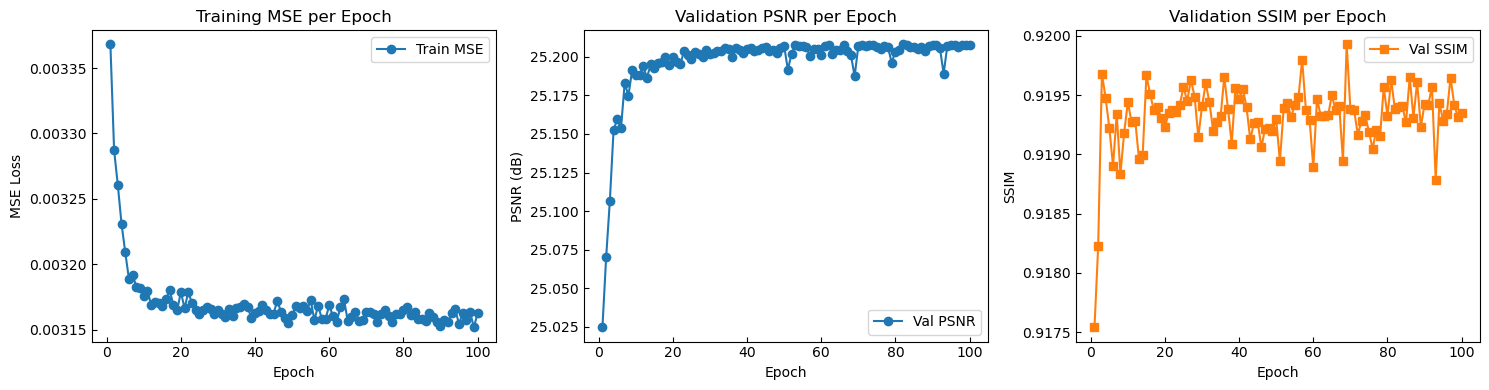

In [34]:
## Training curve visualization: single-phase MSE / PSNR focus

if len(train_loss_list) == 0:
    print("No training data yet. Run the training cell first.")
else:
    epochs_axis = list(range(1, len(train_loss_list) + 1))

    plt.figure(figsize=(15, 4))

    # 1) Training MSE
    plt.subplot(1, 3, 1)
    plt.plot(epochs_axis, train_loss_list, "o-", label="Train MSE")
    plt.title("Training MSE per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.grid(False)
    plt.legend()
    plt.tick_params(direction="in")
    # 2) Validation PSNR
    plt.subplot(1, 3, 2)
    plt.plot(epochs_axis, val_psnr_list, "o-", color="tab:blue", label="Val PSNR")
    plt.title("Validation PSNR per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.grid(False)
    plt.legend()
    plt.tick_params(direction="in")
    # 3) Validation SSIM reference
    plt.subplot(1, 3, 3)
    plt.plot(epochs_axis, val_ssim_list, "s-", color="tab:orange", label="Val SSIM")
    plt.title("Validation SSIM per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("SSIM")
    plt.grid(False)
    plt.legend()
    plt.tick_params(direction="in")
    plt.tight_layout()
    plt.show()

Loaded best PSNR checkpoint: C:\AI_research\outputs\checkpoints\best_model_psnr.pth


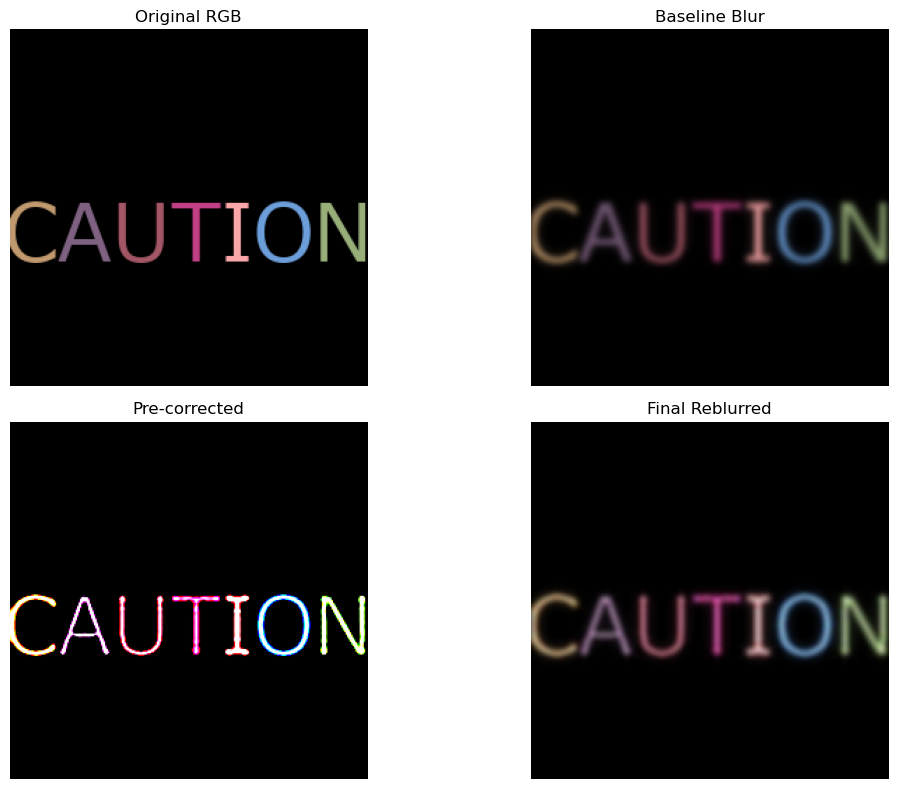

=== Evaluation Result ===
Baseline Blur   → PSNR: 24.01 dB, SSIM: 0.8771
Final Reblurred → PSNR: 25.28 dB, SSIM: 0.8891
Improvement     → ΔPSNR: +1.27 dB, ΔSSIM: +0.0120


In [36]:
# =========================================================
# Cell 14: Evaluation on a Single Test Image
# =========================================================
# This cell evaluates the trained model using one RGB test image.
# The comparison is:
# Original image
# → Baseline blur
# → CNN pre-corrected image
# → Final reblurred image after optical blur simulation

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image

from skimage.metrics import peak_signal_noise_ratio, structural_similarity


# ---------------------------------------------------------
# 1) Paths and setup for image testing
# ---------------------------------------------------------

root = r"C:\AI_research"
img_path = os.path.join(root, "dataset", "test", "signage.png")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 256

best_model_path = os.path.join(ckpt_dir, "best_model_psnr.pth")

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("Loaded best PSNR checkpoint:", best_model_path)
else:
    print("No best PSNR checkpoint found. Using current model state.")

model.to(device)
model.eval()


# ---------------------------------------------------------
# 2) Load and preprocess RGB test image
# ---------------------------------------------------------

sharp_pil = Image.open(img_path).convert("RGB")

transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor()
])

sharp_in = transform(sharp_pil).unsqueeze(0).to(device)  # [1, 3, H, W]


# ---------------------------------------------------------
# 3) Run pre-restoration and blur simulation
# ---------------------------------------------------------

with torch.no_grad():
    # Baseline: original image directly blurred by the PSF
    baseline_blur = reblur_tensor(sharp_in, kernel_tensor)

    # Proposed pipeline: CNN pre-correction followed by the same blur
    precorr = torch.clamp(model(sharp_in), 0.0, 1.0)
    final_reblur = reblur_tensor(precorr, kernel_tensor)

    # Clamp outputs for safe visualization / metric calculation
    baseline_blur = torch.clamp(baseline_blur, 0.0, 1.0)
    final_reblur = torch.clamp(final_reblur, 0.0, 1.0)


# ---------------------------------------------------------
# 4) Convert tensors for visualization
# ---------------------------------------------------------

orig_img = sharp_in.squeeze(0).cpu()
baseline_img = baseline_blur.squeeze(0).cpu()
precorr_img = precorr.squeeze(0).cpu()
final_img = final_reblur.squeeze(0).cpu()

titles = [
    "Original RGB",
    "Baseline Blur",
    "Pre-corrected",
    "Final Reblurred"
]

images = [
    orig_img,
    baseline_img,
    precorr_img,
    final_img
]

plt.figure(figsize=(12, 8))

for i, (img, title) in enumerate(zip(images, titles), 1):
    ax = plt.subplot(2, 2, i)
    ax.imshow(TF.to_pil_image(img))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5) PSNR / SSIM evaluation
# ---------------------------------------------------------

def tensor_to_numpy_rgb(img):
    """
    Convert torch tensor image from CHW format to HWC NumPy format.
    Assumes image values are in [0, 1].
    """
    np_img = img.detach().cpu().numpy()
    np_img = np.transpose(np_img, (1, 2, 0))  # CHW -> HWC
    return np_img.astype(np.float32)


sharp_np = tensor_to_numpy_rgb(orig_img)
blur_np = tensor_to_numpy_rgb(baseline_img)
final_np = tensor_to_numpy_rgb(final_img)

psnr_blur = peak_signal_noise_ratio(sharp_np, blur_np, data_range=1.0)
ssim_blur = structural_similarity(sharp_np, blur_np, data_range=1.0, channel_axis=2)

psnr_final = peak_signal_noise_ratio(sharp_np, final_np, data_range=1.0)
ssim_final = structural_similarity(sharp_np, final_np, data_range=1.0, channel_axis=2)

delta_psnr = psnr_final - psnr_blur
delta_ssim = ssim_final - ssim_blur

print("=== Evaluation Result ===")
print(f"Baseline Blur   → PSNR: {psnr_blur:.2f} dB, SSIM: {ssim_blur:.4f}")
print(f"Final Reblurred → PSNR: {psnr_final:.2f} dB, SSIM: {ssim_final:.4f}")
print(f"Improvement     → ΔPSNR: {delta_psnr:+.2f} dB, ΔSSIM: {delta_ssim:+.4f}")